# Blob Review Phoenix Plan
- 由于电脑损坏维修，原Heat Budget For Blob项目在2023/1/30号之后的文件损坏故需要重新编写  
- 恰好以此为契机，重构Heat Budget For Blob过程  

改动说明：
- 四个变量调整为和CZY同步（daily->monthly mean）
- Clim 时间选取在1980-2020
- 更先进的二维插值函数
- 加速、简洁、正确性

In [1]:
# Module 引入
import os
import datetime
import numpy as np
import scipy as sp
import pandas as pd
import netCDF4 as nc
import PIL.Image as Image
import cartopy.crs as ccrs
import marineHeatWaves as mhw
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
from datetime import date
from tqdm import notebook
from os import listdir
from os.path import join, isfile
from scipy.stats import pearsonr
from scipy.interpolate import RegularGridInterpolator
from scipy.signal import detrend
from matplotlib.backends.backend_agg import FigureCanvasAgg
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from concurrent.futures import ThreadPoolExecutor, ProcessPoolExecutor, Executor


In [2]:
# 常用函数

## 从NC文件时间转PD时间
def cftime2pdtime(cf):
    return pd.to_datetime(datetime.datetime(cf.year,cf.month,cf.day,cf.hour))

## 获取文件夹里所有NC文件
def getfiles(filed):
    files=listdir(filed)
    files.sort()
    files=files[0:]
    files_n=[filed+'/'+i for i in files]
    return files_n

In [3]:
# 常量

YEARL=1980#Clim 基线期起点
YEARR=2020#Clim 基线期终点

LATU=50+0.8
LATD=40-0.8
LONL=225+2
LONR=200-2

## 数据准备

In [4]:
files_mld=getfiles('/lustre/home/yuhanxue/data/Blob/godas/mld')
files_u=getfiles('/lustre/home/yuhanxue/data/Blob/godas/u')
files_v=getfiles('/lustre/home/yuhanxue/data/Blob/godas/v')
files_sst=getfiles('/lustre/home/yuhanxue/data/Blob/godas/sst')

In [5]:
godas_lon=np.array(nc.Dataset(files_mld[0])['lon'])
godas_lat=np.array(nc.Dataset(files_mld[0])['lat'])
godas_lonind=(godas_lon>=LONR)&(godas_lon<=LONL)
godas_latind=(godas_lat>=LATD)&(godas_lat<=LATU)
godas_lon=godas_lon[godas_lonind]
godas_lat=godas_lat[godas_latind]
godas_time=pd.to_datetime(np.concatenate([np.array(list(map(cftime2pdtime,nc.num2date(np.array(nc.Dataset(i).variables['time']),nc.Dataset(i).variables['time'].units)))) for i in files_mld],axis=0))
time_ind=(godas_time.year>=1982)&((godas_time.year<=2020))
godas_levle=np.array(nc.Dataset(files_sst[0])['level'])
godas_mlds=np.concatenate([np.array(nc.Dataset(i)['dbss_obml']) for i in files_mld],axis=0)[time_ind,:,:][:,godas_latind,:][:,:,godas_lonind]
godas_mlds[godas_mlds<-10000]=np.nan
godas_ssts=np.concatenate([np.array(nc.Dataset(i)['pottmp']) for i in files_sst],axis=0)[time_ind,:,:][:,:,godas_latind,:][:,:,:,godas_lonind]
godas_ssts[godas_ssts<-10000]=np.nan
godas_ssts=godas_ssts-273.15
godas_ucur=np.concatenate([np.array(nc.Dataset(i)['ucur']) for i in files_u],axis=0)[time_ind,:,:,:][:,:,godas_latind,:][:,:,:,godas_lonind]
godas_ucur[godas_ucur<-10000]=np.nan
godas_vcur=np.concatenate([np.array(nc.Dataset(i)['vcur']) for i in files_v],axis=0)[time_ind,:,:,:][:,:,godas_latind,:][:,:,:,godas_lonind]
godas_vcur[godas_vcur<-10000]=np.nan

### NCAR数据读取

In [6]:
files_LW='/lustre/home/yuhanxue/data/Blob/ncar/New/nlwrs.sfc.mon.mean.nc'
files_SW='/lustre/home/yuhanxue/data/Blob/ncar/New/nswrs.sfc.mon.mean.nc'
files_LH='/lustre/home/yuhanxue/data/Blob/ncar/New/lhtfl.sfc.mon.mean.nc'
files_SH='/lustre/home/yuhanxue/data/Blob/ncar/New/shtfl.sfc.mon.mean.nc'

In [14]:
ncar_time=pd.to_datetime(list(map(cftime2pdtime,nc.num2date(np.array(nc.Dataset(files_LW).variables['time']),nc.Dataset(files_LW).variables['time'].units))))
ncar_lon=np.array(nc.Dataset(files_LW)['lon'])
ncar_lat=np.array(nc.Dataset(files_LW)['lat'])
print(f'ncar_lat range:{ncar_lat[0]:.2f}~{ncar_lat[-1]:.2f} | freq:{abs(ncar_lat[1]-ncar_lat[0])}\nncar_lon range:{ncar_lon[0]:.2f}~{ncar_lon[-1]:.2f} | freq:{ncar_lon[1]-ncar_lon[0]}')
time_ind=(ncar_time.year>=1982)&((ncar_time.year<=2020))
lonind=(ncar_lon>=LONR-1)&(ncar_lon<=LONL+1)
latind=(ncar_lat>=LATD-1)&(ncar_lat<=LATU+1)
ncar_time=ncar_time[time_ind]
ncar_lon=ncar_lon[lonind]
ncar_lat=ncar_lat[latind]


ncar_LW=np.array(nc.Dataset(files_LW)['nlwrs'])[time_ind,:,:][:,latind,:][:,:,lonind]
ncar_SW=np.array(nc.Dataset(files_SW)['nswrs'])[time_ind,:,:][:,latind,:][:,:,lonind]
ncar_LH=np.array(nc.Dataset(files_LH)['lhtfl'])[time_ind,:,:][:,latind,:][:,:,lonind]
ncar_SH=np.array(nc.Dataset(files_SH)['shtfl'])[time_ind,:,:][:,latind,:][:,:,lonind]

lon_4=godas_lon
lat_4=godas_lat
lon_12=ncar_lon
lat_12=ncar_lat
Lon_4,Lat_4=np.meshgrid(lon_4,lat_4)
print(f'lat_4 range:{lat_4[0]:.2f}~{lat_4[-1]:.2f} | freq:{abs(lat_4[1]-lat_4[0])}\nlon_4 range:{lon_4[0]:.2f}~{lon_4[-1]:.2f} | freq:{lon_4[1]-lon_4[0]}')
print(f'lat_12 range:{lat_12[0]:.2f}~{lat_12[-1]:.2f} | freq:{abs(lat_12[1]-lat_12[0])}\nlon_12 range:{lon_12[0]:.2f}~{lon_12[-1]:.2f} | freq:{lon_12[1]-lon_12[0]}')
def grid(dat):
    global lon_12,lat_12,Lon_4,Lat_4
    #print(dat.shape)
    #f=RegularGridInterpolator((lat_12,lon_12),godas_mlds[1,:,:],bounds_error=False,method='qubic',fill_value=np.nan)
    return RegularGridInterpolator((lat_12,lon_12),dat,bounds_error=False,fill_value=np.nan)((Lat_4,Lon_4))
def list_map(dat):
    pool = ProcessPoolExecutor(max_workers=72)
    ans=np.array(list(pool.map(grid,dat)))
    del pool
    return ans

# pool = ProcessPoolExecutor(max_workers=6)
# godas_mlds=np.array(list(pool.map(list_map,godas_mlds)))
# del pool

ncar_LW=list_map(ncar_LW)
ncar_SW=list_map(ncar_SW)
ncar_LH=list_map(ncar_LH)
ncar_SH=list_map(ncar_SH)


godas_lon=lon_4
godas_lat=lat_4

ncar_lat range:88.54~-88.54 | freq:1.8889007568359375
ncar_lon range:0.00~358.12 | freq:1.875
lat_4 range:39.83~50.17 | freq:0.3333282470703125
lon_4 range:199.50~225.50 | freq:1.0
lat_12 range:50.48~39.05 | freq:1.9047012329101562
lon_12 range:198.75~226.88 | freq:1.875


### ERSST

In [15]:
# ERSST
ersst=nc.Dataset('/lustre/home/yuhanxue/data/Blob/ersst/sst.nc')
ersst_time=pd.to_datetime(np.array(list(map(cftime2pdtime,nc.num2date(np.array(ersst.variables['time']),ersst.variables['time'].units)))))
time_ind=(ersst_time.year>=1980)&((ersst_time.year<=2020))
ersst_lat=np.array(ersst['lat'])
ersst_lon=np.array(ersst['lon'])
ersst_lonind=(ersst_lon>=LONR-2)&(ersst_lon<=LONL+2)
ersst_latind=(ersst_lat>=LATD-2)&(ersst_lat<=LATU+2)
ersst_lon=ersst_lon[ersst_lonind]
ersst_lat=ersst_lat[ersst_latind]
ersst_sst=np.array(ersst['sst'])[time_ind,:,:][:,ersst_latind,:][:,:,ersst_lonind]
ersst_sst[ersst_sst<-1000]=np.nan
ersst_time=ersst_time[time_ind]

lon_4=godas_lon
lat_4=godas_lat
lon_12=ersst_lon
lat_12=ersst_lat
Lon_4,Lat_4=np.meshgrid(lon_4,lat_4)
print(f'lat_4 range:{lat_4[0]:.2f}~{lat_4[-1]:.2f} | freq:{abs(lat_4[1]-lat_4[0])}\nlon_4 range:{lon_4[0]:.2f}~{lon_4[-1]:.2f} | freq:{lon_4[1]-lon_4[0]}')
print(f'lat_12 range:{lat_12[0]:.2f}~{lat_12[-1]:.2f} | freq:{abs(lat_12[1]-lat_12[0])}\nlon_12 range:{lon_12[0]:.2f}~{lon_12[-1]:.2f} | freq:{lon_12[1]-lon_12[0]}')
def grid(dat):
    global lon_12,lat_12,Lon_4,Lat_4
    #print(dat.shape)
    #f=RegularGridInterpolator((lat_12,lon_12),godas_mlds[1,:,:],bounds_error=False,method='qubic',fill_value=np.nan)
    return RegularGridInterpolator((lat_12,lon_12),dat,bounds_error=False,fill_value=np.nan)((Lat_4,Lon_4))
def list_map(dat):
    pool = ProcessPoolExecutor(max_workers=72)
    ans=np.array(list(pool.map(grid,dat)))
    del pool
    return ans
# pool = ProcessPoolExecutor(max_workers=6)
# ersst=np.array(list(pool.map(list_map,ersst)))
# del pool
ersst_sst=list_map(ersst_sst)
ersst_lon=lon_4
ersst_lat=lat_4

lat_4 range:39.83~50.17 | freq:0.3333282470703125
lon_4 range:199.50~225.50 | freq:1.0
lat_12 range:52.00~38.00 | freq:2.0
lon_12 range:196.00~228.00 | freq:2.0


### 洋葱皮，扒一层

In [16]:
godas_lat=godas_lat[1:-1]
godas_lon=godas_lon[1:-1]
godas_mlds=godas_mlds[:,1:-1,1:-1]
godas_ssts=godas_ssts[:,:,1:-1,1:-1]
godas_ucur=godas_ucur[:,:,1:-1,1:-1]
godas_vcur=godas_vcur[:,:,1:-1,1:-1]

ncar_lat=ncar_lat[1:-1]
ncar_lon=ncar_lon[1:-1]
ncar_LH=ncar_LH[:,1:-1,1:-1]
ncar_LW=ncar_LW[:,1:-1,1:-1]
ncar_SH=ncar_SH[:,1:-1,1:-1]
ncar_SW=ncar_SW[:,1:-1,1:-1]

ersst_lat=ersst_lat[1:-1]
ersst_lon=ersst_lon[1:-1]
ersst_sst=ersst_sst[:,1:-1,1:-1]

## 计算

### $Q$ 表面净热通量总和


$$
Q=\frac{Q_{net}-Q_{z}}{\rho_{0}C_{p}h}
$$
- $Q_{net}=Q_{ShortwaveRadiation}+Q_{LongwaveRadiation}+Q_{LatentHeatFlux}+Q_{SensibleHeatFlux}$
- $Q_{z}=Q_{ShortwaveRadiation}(0.58e^{\frac{h}{0.35}}+0.42e^\frac{h}{23})$
- $\rho _{0}: 1.024 g/cm^{3}$
- $C_{p}: 3850 J\cdot kg^{-1} \cdot C^{-1}$



In [17]:
CATIME=ncar_time
def clim_core(dat):
    global CATIME
    return np.array([np.nanmean(dat[CATIME.month==i]) for i in range(1,13)])
def list_map_clim(dat):
    ans=np.array(list(map(clim_core,dat)))
    return ans
def Clim_allinone(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    ans=np.array(list(map(list_map_clim,a)))
    ans=np.swapaxes(ans,1,2)
    ans=np.swapaxes(ans,0,1)
    return ans
def Ano_allinone(dat):    
    return dat-np.tile(Clim_allinone(dat), (np.unique(CATIME.year).shape[0], 1, 1))

def list_map_detrend(dat):
    ans=np.array(list(map(detrend,dat)))
    return ans
def detrend_allinone(dat):
    a=np.swapaxes(dat,0,1)
    a=np.swapaxes(a,1,2)
    ans=np.array(list(map(list_map_detrend,a)))
    ans=np.swapaxes(ans,1,2)
    ans=np.swapaxes(ans,0,1)
    return ans


Q_net=detrend_allinone((ncar_LH+ncar_LW+ncar_SH+ncar_SW)*-1)
Q_z=ncar_SW*(0.58*np.exp(godas_mlds/0.35)+0.42*np.exp(godas_mlds/23))
Q=Ano_allinone(detrend_allinone(Q_net/(4.088e6*godas_mlds)))*24*3600*30

/tmp/ipykernel_317461/2655452991.py:31: RuntimeWarning: overflow encountered in exp
  Q_z=ncar_SW*(0.58*np.exp(godas_mlds/0.35)+0.42*np.exp(godas_mlds/23))


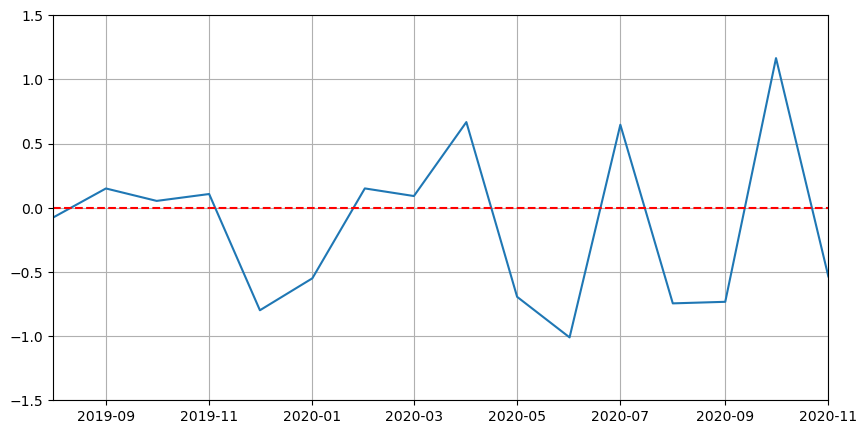

In [18]:
plt.figure(figsize=(10,5))
plt.plot(ncar_time,np.mean(np.mean(Q,axis=-1),axis=-1))
plt.xlim(ncar_time[(ncar_time.year==2019)&(ncar_time.month==8)],ncar_time[(ncar_time.year==2020)&(ncar_time.month==11)])
plt.axhline(y=0, color='r', linestyle='--')
plt.ylim(-1.5,1.5)
plt.grid()

[]

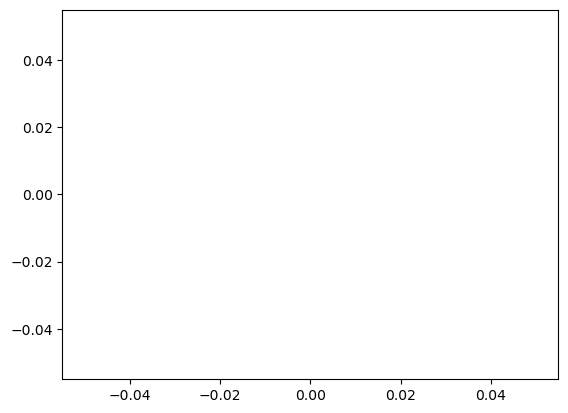

In [17]:
plt.plot()

### Mixed Layer Temperature Tendency

$$
Mixed Layer Temperature Tendency=\frac{\mathrm{d}\mathrm{T_{m}}}{\mathrm{d}\mathrm{t}}
$$

In [18]:
#1 计算MLT
mlt_grid_level=np.broadcast_to(godas_levle[np.newaxis,:,np.newaxis,np.newaxis],godas_ssts.shape)
selector = mlt_grid_level >= np.broadcast_to(godas_mlds[:, np.newaxis, ...], godas_ssts.shape)
potential_t_below_mld = np.ma.masked_array(godas_ssts, mask=selector)
mlt=np.array(np.nanmean(potential_t_below_mld,axis=1))
mltt=mlt[:-1,:,:]-mlt[1:,:,:]